In [ ]:
import pandas as pd #data handling
import numpy as np #numeric
import matplotlib.pyplot as plt #plots

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 12100168.csv to 12100168.csv


In [ ]:
df = pd.read_csv(list(uploaded.keys())[0])
df.head()

,REF_DATE,GEO,DGUID,Trade,Basis,Seasonal adjustment,Index,Weighting,North American Product Classification System (NAPCS),UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2017-01,Canada,2021A000011124,Import,Customs,Unadjusted,Price index,Paasche current weighted,Total of all merchandise,"Index, 2017=100",373,units,0,v1566912759,1.1.1.1.1.1.1,100.6,NaN,NaN,NaN,1
1,2017-01,Canada,2021A000011124,Import,Customs,Unadjusted,Price index,Paasche current weighted,"Farm, fishing and intermediate food products [...","Index, 2017=100",373,units,0,v1566912760,1.1.1.1.1.1.2,100.3,NaN,NaN,NaN,1
2,2017-01,Canada,2021A000011124,Import,Customs,Unadjusted,Price index,Paasche current weighted,Farm and fishing products [C111],"Index, 2017=100",373,units,0,v1566912761,1.1.1.1.1.1.3,100.1,NaN,NaN,NaN,1
3,2017-01,Canada,2021A000011124,Import,Customs,Unadjusted,Price index,Paasche current weighted,Live animals [111],"Index, 2017=100",373,units,0,v1566912762,1.1.1.1.1.1.4,109.4,NaN,NaN,NaN,1
4,2017-01,Canada,2021A000011124,Import,Customs,Unadjusted,Price index,Paasche current weighted,Wheat [112],"Index, 2017=100",373,units,0,v1566912763,1.1.1.1.1.1.5,94.0,NaN,NaN,NaN,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 389052 entries, 0 to 389051
Data columns (total 20 columns):
 #   Column                                                Non-Null Count   Dtype  
---  ------                                                --------------   -----  
 0   REF_DATE                                              389052 non-null  object 
 1   GEO                                                   389052 non-null  object 
 2   DGUID                                                 389052 non-null  object 
 3   Trade                                                 389052 non-null  object 
 4   Basis                                                 389052 non-null  object 
 5   Seasonal adjustment                                   389052 non-null  object 
 6   Index                                                 389052 non-null  object 
 7   Weighting                                             389052 non-null  object 
 8   North American Product Classification System

In [ ]:
df.describe()

,UOM_ID,SCALAR_ID,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
count,389052.0,389052.0,389052.000000,0.0,0.0,0.0,389052.0
mean,373.0,0.0,114.179791,NaN,NaN,NaN,1.0
std,0.0,0.0,33.880184,NaN,NaN,NaN,0.0
min,373.0,0.0,0.000000,NaN,NaN,NaN,1.0
25%,373.0,0.0,99.200000,NaN,NaN,NaN,1.0
50%,373.0,0.0,106.600000,NaN,NaN,NaN,1.0
75%,373.0,0.0,124.700000,NaN,NaN,NaN,1.0
max,373.0,0.0,2136.200000,NaN,NaN,NaN,1.0


In [ ]:
#Making Sure dates aare in order
df['REF_DATE'] = pd.to_datetime(df['REF_DATE'])
df = df.sort_values('REF_DATE')

In [ ]:
df['REF_DATE'].min(), df['REF_DATE'].max()

(Timestamp('2017-01-01 00:00:00'), Timestamp('2025-11-01 00:00:00'))

In [ ]:
df[['REF_DATE']].head()

,REF_DATE
0,2017-01-01
2417,2017-01-01
2418,2017-01-01
2419,2017-01-01
2420,2017-01-01


In [ ]:
df[['REF_DATE']].tail()

,REF_DATE
386631,2025-11-01
386632,2025-11-01
386633,2025-11-01
386607,2025-11-01
389051,2025-11-01


In [ ]:
df.columns

Index(['REF_DATE', 'GEO', 'DGUID', 'Trade', 'Basis', 'Seasonal adjustment',
       'Index', 'Weighting',
       'North American Product Classification System (NAPCS)', 'UOM', 'UOM_ID',
       'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE', 'STATUS',
       'SYMBOL', 'TERMINATED', 'DECIMALS'],
      dtype='object')

In [ ]:
df['North American Product Classification System (NAPCS)'].unique()

array(['Total of all merchandise', 'Special transactions trade [988]',
       'Farm, fishing and intermediate food products [C11]',
       'Farm and fishing products [C111]', 'Live animals [111]',
       'Wheat [112]', 'Canola (including rapeseed) [113]',
       'Fresh fruit, nuts and vegetables, and pulse crops [114]',
       'Other crop products [115]', 'Other animal products [116]',
       'Fish, crustaceans, shellfish and other fishery products [121]',
       'Special transactions trade [C231]', 'Animal feed [181]',
       'Intermediate food products [182]', 'Energy products [C12]',
       'Crude oil and crude bitumen [C121]',
       'Crude oil and bitumen [141]',
       'Natural gas, natural gas liquids and related products [C122]',
       'Natural gas [142]',
       'Natural gas liquids (including condensate) and related products [143]',
       'Coal [C123]', 'Coal [144]',
       'Nuclear fuel and other energy products [C124]',
       'Nuclear fuel and other energy products [145]

In [ ]:
UniCat = df['North American Product Classification System (NAPCS)'].dropna().sort_values().unique()
UniCat

array(['Agricultural, lawn and garden machinery and equipment [331]',
       'Aircraft [421]',
       'Aircraft and other transportation equipment and parts [C21]',
       'Aircraft engines, aircraft parts and other aerospace equipment [431]',
       'Aircraft, aircraft engines and aircraft parts [C211]',
       'Alcoholic beverages [211]', 'Animal feed [181]',
       'Appliances [382]',
       'Asphalt (except natural) and asphalt products [262]',
       'Basic and industrial chemical, plastic and rubber products [C15]',
       'Basic and semi-finished iron or steel products [312]',
       'Basic and semi-finished products of aluminum and aluminum alloys [327]',
       'Basic and semi-finished products of non-ferrous metals and non-ferrous metal alloys (except aluminum) [326]',
       'Basic chemicals [271]',
       'Basic chemicals and industrial chemical products [C151]',
       'Boats and other transportation equipment [442]',
       'Building and packaging materials [C163]',
     

In [ ]:
df['North American Product Classification System (NAPCS)'].value_counts()

,count
North American Product Classification System (NAPCS),
Total of all merchandise,2568
Special transactions trade [988],2568
"Farm, fishing and intermediate food products [C11]",2568
Farm and fishing products [C111],2568
Live animals [111],2568
...,...
"Agricultural, lawn and garden machinery and equipment [331]",2568
"Logging, construction, mining, and oil and gas field machinery and equipment [332]",2568
Other balance of payments adjustments [C24],1284


In [ ]:
catCol = 'North American Product Classification System (NAPCS)'

catTable = pd.DataFrame(
    df[catCol].dropna().unique(),
    columns=['Category']
)

catTable

,Category
0,Total of all merchandise
1,Special transactions trade [988]
2,"Farm, fishing and intermediate food products [..."
3,Farm and fishing products [C111]
4,Live animals [111]
...,...
148,"Agricultural, lawn and garden machinery and eq..."
149,"Logging, construction, mining, and oil and gas..."
150,Other balance of payments adjustments [C24]
151,Other balance of payments adjustments [C241]


In [ ]:
selectedGroups = [
    "Furniture and fixtures [C225]","Furniture and fixtures [391]",
    "Clothing, footwear and textile products [C222]", "Clothing, footwear and accessories [231]",
    "Canola (including rapeseed) [113]",
    "Fresh fruit, nuts and vegetables, and pulse crops [114]"
]

dfFiltered = df[df['North American Product Classification System (NAPCS)'].isin(selectedGroups)]

dfFiltered

,REF_DATE,GEO,DGUID,Trade,Basis,Seasonal adjustment,Index,Weighting,North American Product Classification System (NAPCS),UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
2423,2017-01-01,Canada,2021A000011124,Export,Customs,Seasonally adjusted,Price index,Laspeyres fixed weighted,Canola (including rapeseed) [113],"Index, 2017=100",373,units,0,v1566915182,1.2.1.2.1.2.6,98.4,NaN,NaN,NaN,1
2424,2017-01-01,Canada,2021A000011124,Export,Customs,Seasonally adjusted,Price index,Laspeyres fixed weighted,"Fresh fruit, nuts and vegetables, and pulse cr...","Index, 2017=100",373,units,0,v1566915183,1.2.1.2.1.2.7,100.7,NaN,NaN,NaN,1
2399,2017-01-01,Canada,2021A000011124,Export,Customs,Seasonally adjusted,Price index,Paasche current weighted,"Clothing, footwear and textile products [C222]","Index, 2017=100",373,units,0,v1566915158,1.2.1.2.1.1.132,100.2,NaN,NaN,NaN,1
2409,2017-01-01,Canada,2021A000011124,Export,Customs,Seasonally adjusted,Price index,Paasche current weighted,Furniture and fixtures [C225],"Index, 2017=100",373,units,0,v1566915168,1.2.1.2.1.1.142,99.8,NaN,NaN,NaN,1
2410,2017-01-01,Canada,2021A000011124,Export,Customs,Seasonally adjusted,Price index,Paasche current weighted,Furniture and fixtures [391],"Index, 2017=100",373,units,0,v1566915169,1.2.1.2.1.1.143,99.8,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
386602,2025-11-01,Canada,2021A000011124,Import,Balance of payments,Unadjusted,Price index,Laspeyres fixed weighted,"Clothing, footwear and accessories [231]","Index, 2017=100",373,units,0,v1566913945,1.1.2.1.1.2.134,101.7,NaN,NaN,NaN,1
386610,2025-11-01,Canada,2021A000011124,Import,Balance of payments,Unadjusted,Price index,Laspeyres fixed weighted,Furniture and fixtures [C225],"Index, 2017=100",373,units,0,v1566913953,1.1.2.1.1.2.142,132.7,NaN,NaN,NaN,1
386611,2025-11-01,Canada,2021A000011124,Import,Balance of payments,Unadjusted,Price index,Laspeyres fixed weighted,Furniture and fixtures [391],"Index, 2017=100",373,units,0,v1566913954,1.1.2.1.1.2.143,132.7,NaN,NaN,NaN,1
386627,2025-11-01,Canada,2021A000011124,Import,Balance of payments,Unadjusted,Volume index,Laspeyres fixed weighted,Canola (including rapeseed) [113],"Index, 2017=100",373,units,0,v1566913970,1.1.2.1.2.2.6,166.9,NaN,NaN,NaN,1


In [ ]:
dfSelected = df[df[catCol].isin(selectedGroups)].copy()

dfSelected[catCol].value_counts()

,count
North American Product Classification System (NAPCS),
Canola (including rapeseed) [113],2568
"Fresh fruit, nuts and vegetables, and pulse crops [114]",2568
"Clothing, footwear and textile products [C222]",2568
Furniture and fixtures [C225],2568
Furniture and fixtures [391],2568
"Clothing, footwear and accessories [231]",2568


In [ ]:
trade = 'Trade'
index = 'Index'
seasonal = 'Seasonal adjustment'
weight = 'Weighting'
basis = 'Basis'

In [ ]:
dfModelBase = dfSelected[
    (dfSelected[trade] == 'Import') &   # Imports only for import demand
    (dfSelected[index] == 'Volume index') & # volume index means quantity(or demand)
    (dfSelected[seasonal] == 'Seasonally adjusted') & #keeping only seasonally adjusted data for now, will revisit this later
    (dfSelected[basis] == 'Customs') #measuring only on basis of customs    #used & to make sure all conditions are true.
].copy()

print("Rows after Import+Volume+SA+Customs:", len(dfModelBase))

Rows after Import+Volume+SA+Customs: 642


In [ ]:
dfEda = dfSelected[
    (dfSelected['Trade'] == 'Import') &
    (dfSelected['Index'] == 'Volume index')
].copy()

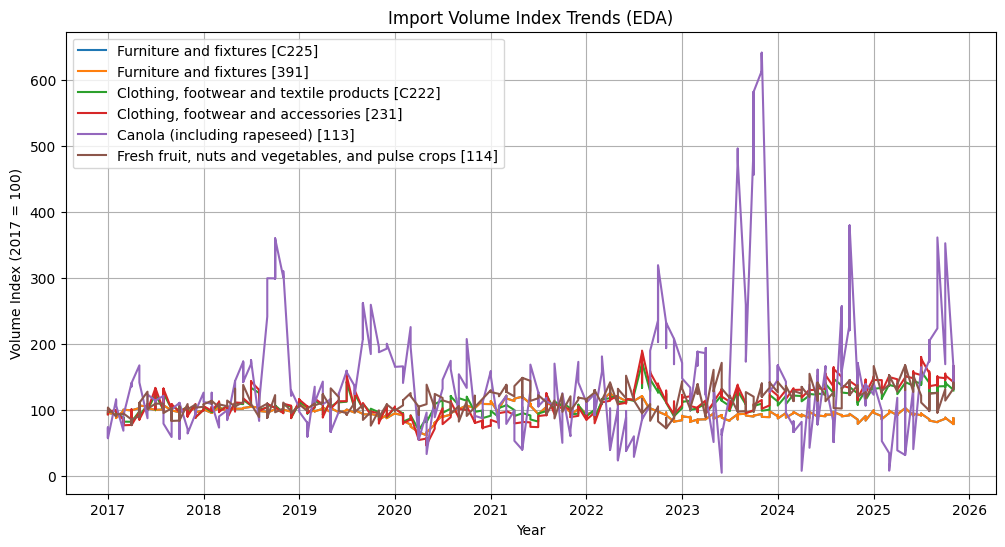

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for group in selectedGroups:
    subsetDf = dfEda[dfEda[catCol] == group].sort_values('REF_DATE')
    plt.plot(subsetDf['REF_DATE'], subsetDf['VALUE'], label=group)

plt.title("Import Volume Index Trends (EDA)")
plt.xlabel("Year")
plt.ylabel("Volume Index (2017 = 100)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:

def group_category(category):
    if category in ["Furniture and fixtures [C225]", "Furniture and fixtures [391]"]:
        return "Furniture and Fixtures"
    elif category in ["Clothing, footwear and textile products [C222]", "Clothing, footwear and accessories [231]"]:
        return "Clothing and Footwear"
    elif category in ["Canola (including rapeseed) [113]", "Fresh fruit, nuts and vegetables, and pulse crops [114]"]:
        return "Agricultural Products"
    return category

dfEda['Grouped Category'] = dfEda[catCol].apply(group_category)
dfEda['Grouped Category'].value_counts()

,count
Grouped Category,
Clothing and Footwear,856
Furniture and Fixtures,856
Agricultural Products,856


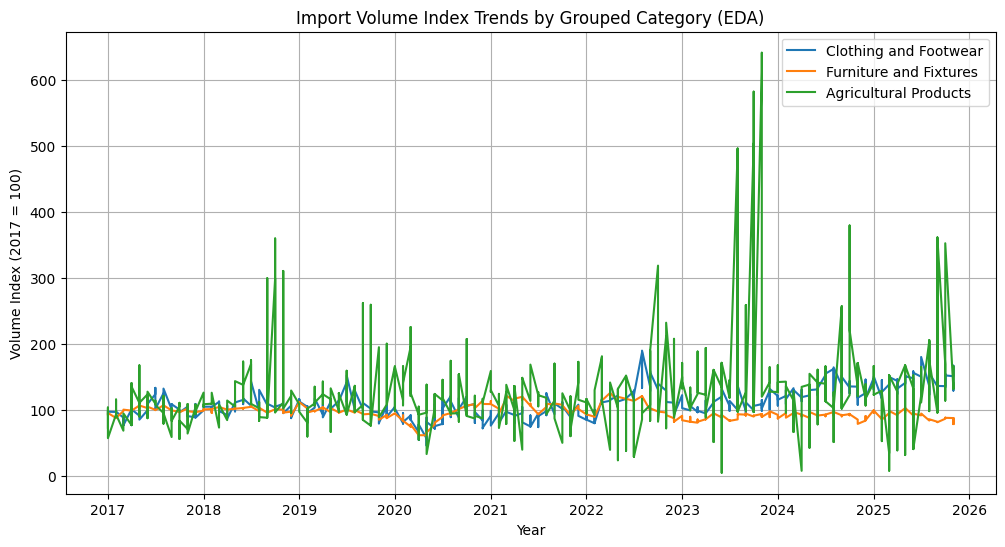

In [ ]:
plt.figure(figsize=(12, 6))

for group in dfEda['Grouped Category'].unique():
    subsetDf = dfEda[dfEda['Grouped Category'] == group].sort_values('REF_DATE')
    plt.plot(subsetDf['REF_DATE'], subsetDf['VALUE'], label=group)

plt.title("Import Volume Index Trends by Grouped Category (EDA)")
plt.xlabel("Year")
plt.ylabel("Volume Index (2017 = 100)")
plt.legend()
plt.grid(True)
plt.show()